# 🚀 트랜스포머 심화 실습 (Advanced Engineering)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import logging
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)

import matplotlib.pyplot as plt
if os.name == 'nt':
    plt.rc('font', family='Malgun Gothic') # 윈도우 맑은 고딕
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
import seaborn as sns

## 1. BERT 내부 Attention Map 시각화
사전 학습된 트랜스포머 모델을 불러와 `bertviz`를 이용해 문장 내에서 어텐션 헤드들이 어떻게 동작하는지 직관적으로 확인해 봅니다.

In [2]:
from transformers import AutoTokenizer, AutoModel
from bertviz import head_view
import torch

# HuggingFace 로깅 레벨 조정 (경고 억제)
import transformers
transformers.logging.set_verbosity_error()

# 모델과 토크나이저 로드 (소형 BERT 모델)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_attentions=True)

# 테스트 문장
text = "The animal didn't cross the street because it was too tired."
inputs = tokenizer(text, return_tensors="pt")

# 모델 추론
outputs = model(**inputs)
attentions = outputs.attentions  # 각 레이어별 어텐션 가중치 목록
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

print("로드된 토큰 목록:", tokens)
print(f"총 레이어 수: {len(attentions)}, 각 레이어당 Head 수: {attentions[0].shape[1]}")

# 주의: bertviz는 Jupyter 내장 위젯이나 HTML 렌더링이 필요하여 nbconvert 실행 시 빈 공간으로 남을 수 있습니다.
# 로컬 Jupyter 환경에서 실행 시 동적 인터랙티브 뷰를 볼 수 있습니다.
html_head_view = head_view(attentions, tokens, html_action='return')
from IPython.display import HTML
HTML(html_head_view.data[:1000] + "... (인터랙티브 뷰는 로컬 환경에서 확인 가능)") # 출력이 너무 길어지는 것 방지


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

로드된 토큰 목록: ['[CLS]', 'the', 'animal', 'didn', "'", 't', 'cross', 'the', 'street', 'because', 'it', 'was', 'too', 'tired', '.', '[SEP]']
총 레이어 수: 6, 각 레이어당 Head 수: 12


## 2. 행렬 연산 병목: 시퀀스 길이에 따른 $O(N^2)$ 시간 분석
트랜스포머의 Self-Attention 연산 $Q \cdot K^T$는 시퀀스 길이 $N$에 대해 $O(N^2)$의 연산량을 가집니다. 문장이 길어질수록 연산 시간이 어떻게 증가하는지 실험해 봅니다.

시퀀스 길이에 따른 어텐션 연산 시간 (ms)
Length   16 : 0.9653 ms


Length   64 : 1.4552 ms


Length  128 : 3.0692 ms


Length  256 : 7.1783 ms


Length  512 : 29.6502 ms


Length 1024 : 74.4467 ms


Length 2048 : 163.4230 ms


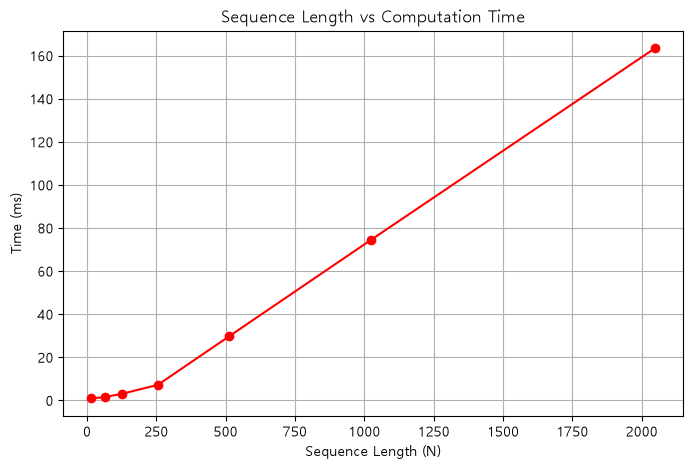

👉 결론: 시퀀스 길이가 증가할수록 연산 시간이 O(N^2) 곡선을 그리며 급격히 증가함을 알 수 있습니다. 이 때문에 트랜스포머는 아주 긴 문서(소설 전체 등)를 한 번에 처리하는 데 한계가 있으며, 이를 극복하기 위해 Longformer 등 다양한 후속 연구가 진행되었습니다.


In [3]:
import time

def measure_attention_time(seq_len, d_model=512, num_heads=8):
    mha = MultiHeadAttention(d_model, num_heads)
    # 평가 모드 설정
    mha.eval()
    
    dummy_input = torch.randn(1, seq_len, d_model)
    
    # 웜업 (CPU 캐시 초기화 등 변인 통제)
    for _ in range(5):
        _ = mha(dummy_input, dummy_input, dummy_input)
        
    start_time = time.perf_counter()
    # 100번 반복 측정
    for _ in range(100):
        _ = mha(dummy_input, dummy_input, dummy_input)
    end_time = time.perf_counter()
    
    return (end_time - start_time) / 100 * 1000 # 밀리초(ms) 반환

# MultiHeadAttention 클래스를 로컬에 복사 (02번 노트북에서 구현한 것 재사용)
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        
    def forward(self, q, k, v):
        batch_size = q.size(0)
        Q = self.W_q(q).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(k).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(v).view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, V)
        
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)
        return self.W_o(out)

# 실험 시작
seq_lengths = [16, 64, 128, 256, 512, 1024, 2048]
times = []

print("시퀀스 길이에 따른 어텐션 연산 시간 (ms)")
for length in seq_lengths:
    t = measure_attention_time(length)
    times.append(t)
    print(f"Length {length:4d} : {t:.4f} ms")

# 시각화
plt.figure(figsize=(8, 5))
plt.plot(seq_lengths, times, marker='o', linestyle='-', color='r')
plt.title("Sequence Length vs Computation Time")
plt.xlabel("Sequence Length (N)")
plt.ylabel("Time (ms)")
plt.grid(True)
plt.show()

print("👉 결론: 시퀀스 길이가 증가할수록 연산 시간이 O(N^2) 곡선을 그리며 급격히 증가함을 알 수 있습니다. 이 때문에 트랜스포머는 아주 긴 문서(소설 전체 등)를 한 번에 처리하는 데 한계가 있으며, 이를 극복하기 위해 Longformer 등 다양한 후속 연구가 진행되었습니다.")